In [332]:
import allensdk
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorNeuropixelsProjectCache
import tqdm
from scipy.ndimage import gaussian_filter1d
import pre_process_spikes as pps
import process_model as pm
import LSTMnet as lstm 
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import sys

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
output_dir = r"Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022"
output_dir = Path(output_dir)
cache = VisualBehaviorNeuropixelsProjectCache.from_s3_cache(cache_dir=output_dir)
session_id = 1044385384 # Arbitrary pick
session = cache.get_ecephys_session(ecephys_session_id=session_id)
behavior_id = session.behavior_session_id
behavior = cache.get_behavior_session(behavior_id)
chan = session.get_channels()

c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\allensdk\api\cloud_cache\cloud_cache.py:547: OutdatedManifestWarning: You are loading visual-behavior-neuropixels_project_manifest_v0.4.0.json. A more up to date version of the dataset -- visual-behavior-neuropixels_project_manifest_v0.5.0.json -- exists online. To see the changes between the two versions of the dataset, run
VisualBehaviorNeuropixelsProjectCache.compare_manifests('visual-behavior-neuropixels_project_manifest_v0.4.0.json', 'visual-behavior-neuropixels_project_manifest_v0.5.0.json')
To load another version of the dataset, run
VisualBehaviorNeuropixelsProjectCache.load_manifest('visual-behavior-neuropixels_project_manifest_v0.5.0.json')
  warnings.warn(msg, OutdatedManifestWarning)
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s

In [3]:
units = session.get_units()
channels = session.get_channels()
spike_times = session.spike_times
units = units.merge(channels, left_on='peak_channel_id', right_index=True)
units = units[(units.isi_violations < 0.5) &
                                      (units.presence_ratio > 0.9) &
                                      (units.amplitude_cutoff < 0.1) &
                                      (units.firing_rate > 0.1)]

In [195]:
bin_size = 0.004
start = int(behavior.stimulus_presentations.start_time[behavior.stimulus_presentations.active].iloc[1])
stop  = int(behavior.stimulus_presentations.end_time[behavior.stimulus_presentations.active].iloc[-1])


In [198]:
spikes_obj = pps.pre_process_spikes(units, spike_times,bin_size=0.004, sigma=3)
spikes_obj.getSpkMat(start, stop)
spikes_obj.convolve_with_gaussian()
spikes_obj.zscore()

100%|██████████| 741/741 [01:02<00:00, 11.93it/s]


In [ ]:
probeC = session.get_lfp(session.probes[session.probes.name == 'probeC'].index[0])
# channel ids for VISp
visp_df = chan.loc[probeC.channel][chan.loc[probeC.channel]['structure_acronym'].str.contains('VISp')]
lfp_slice = probeC.sel(time=slice(start,stop), channel=visp_df.index)
# resample data from 1250 Hz to 250 Hz to match the spike data
data = stats.zscore(lfp_slice[::5,:].values, axis=0) 
print(data.shape)
print(spikes_obj.spkMat.shape)
# make sure the data is the same length as the spike data
if data.shape[0] > spikes_obj.spkMat.shape[0]:
    data = data[:spikes_obj.spkMat.shape[0],:]

c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.5.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


In [ ]:
input_size = spikes_obj.spkMat.shape[1]
hidden_size = 50
num_layers = 1
seqlength = 750

In [ ]:
# Preprocess data
num_trials = int(data.shape[0] / seqlength)
X = spikes_obj.spkMat[:num_trials * seqlength, :]
lfp = data[:num_trials * seqlength, :]

X_reshaped = np.reshape(X, (num_trials, seqlength, X.shape[1]))
lfp_reshaped = np.reshape(lfp, (num_trials, seqlength, lfp.shape[1]))

X_train, X_test, y_train, y_test = train_test_split(X_reshaped, lfp_reshaped, test_size=0.2, random_state=42)

X_train = X_train.reshape(X_train.shape[0] * X_train.shape[1], X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0] * X_test.shape[1], X_test.shape[2])

y_train = y_train.reshape(y_train.shape[0] * y_train.shape[1], y_train.shape[2])
y_test = y_test.reshape(y_test.shape[0] * y_test.shape[1], y_test.shape[2]) 

X_trainT = torch.tensor(X_train).float()
y_trainT = torch.tensor(y_train).float()
X_testT = torch.tensor(X_test).float()
y_testT = torch.tensor(y_test).float()

# remove non-tensor variables to free up memory
del X, lfp, X_reshaped, lfp_reshaped, X_train, X_test, y_train, y_test

print(X_trainT.shape, y_trainT.shape)
print(X_testT.shape, y_testT.shape)

torch.Size([720000, 741]) torch.Size([720000, 20])
torch.Size([180750, 741]) torch.Size([180750, 20])


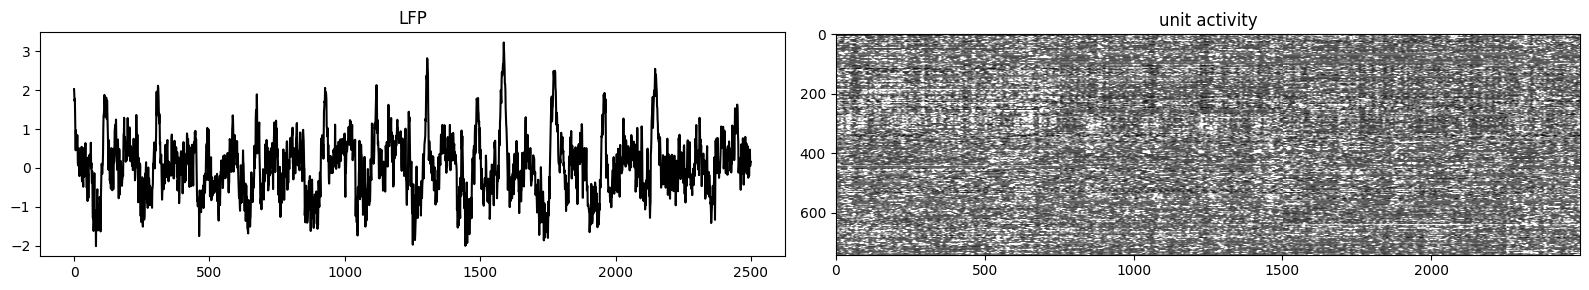

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(16, 3))

ax[0].plot(y_trainT.numpy()[:int(10/bin_size),10],'k',label='LFP')
# ax[0].plot(stats.zscore(np.mean(X_trainT.cpu().detach().numpy()[:int(10/bin_size),:], axis=1)),'r',label='unit activity')
ax[0].set_title('LFP')

ax[1].imshow(X_trainT.numpy()[:int(10/bin_size),:].T, vmin=-1, vmax=1, cmap='gray')
ax[1].set_title('unit activity')

plt.tight_layout()
plt.show()

In [ ]:
criterion = torch.nn.MSELoss()
lossesAll = []
# initialize dictionary to store trained models 
models = {}

for chani in range(y_trainT.shape[1]):
    sys.stdout.write('\r' + 'Training model for channel ' + str(chani) + ' out of ' + str(y_trainT.shape[1]))
    model = lstm.LSTMnet(input_size, hidden_size, num_layers)
    mdl   = pm.process_model(model, seqlength, criterion, device)
    models[chani] = mdl
    losses = mdl.train(X_trainT, y_trainT[:,chani].unsqueeze(1) , 15)
    lossesAll.append(losses)

Training model for channel 0 out of 20

c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Finished epoch 11/15hannel 16 out of 20

Text(0.5, 1.0, 'Model loss')

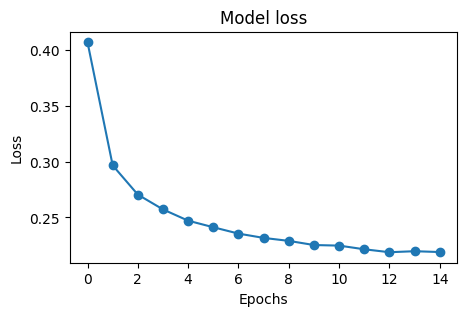

In [322]:
fig,ax = plt.subplots(1,1,figsize=(5,3))

ax.plot(losses,'o-')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Model loss')

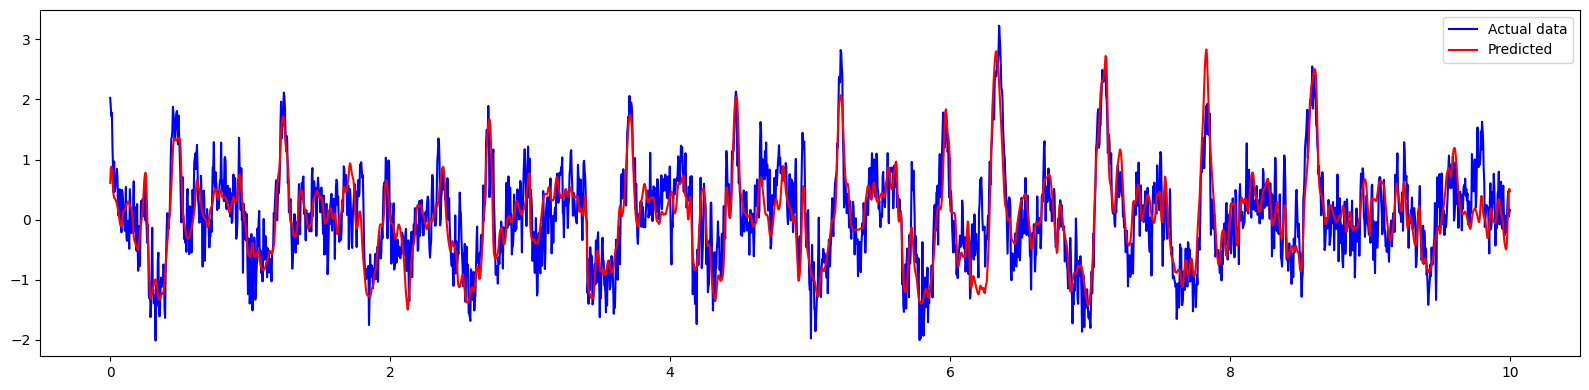

R2 score train data: 0.7783500706418354


In [ ]:
yHat_train = mdl.evaluate(X_trainT)

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(np.linspace(0,10,int(10/bin_size)) ,y_trainT.numpy()[:int(10/bin_size),10],'b',label='Actual data')
# ax.plot(power_train[:int(10/bin_size),4],'b',label='Actual data')

ax.plot(np.linspace(0,10,int(10/bin_size)) ,yHat_train[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()

# print R2
print(f'R2 score train data: {r2_score(y_trainT[:,10].cpu().detach().numpy(), yHat_train)}')

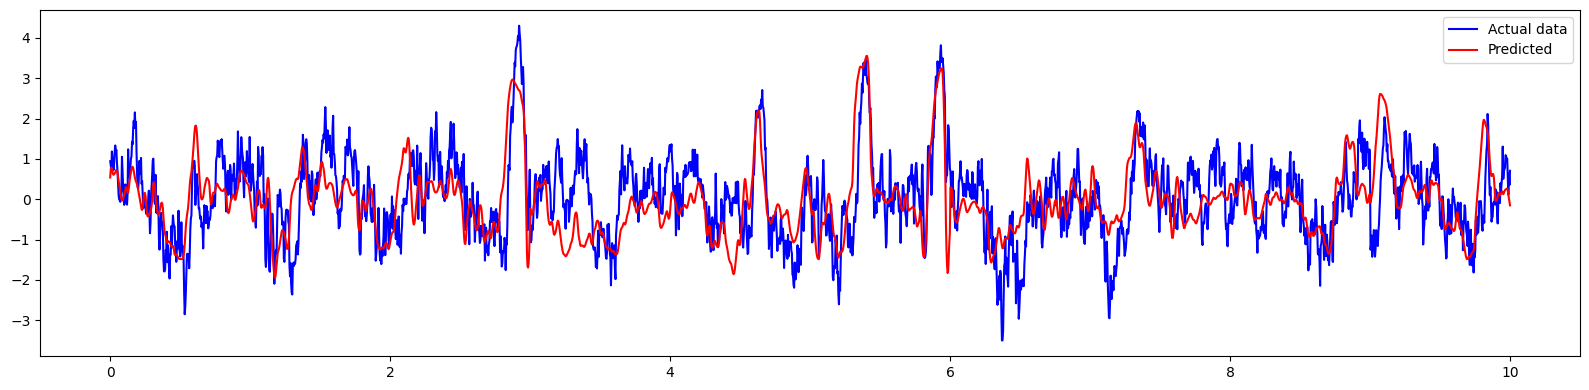

R2 score train data: 0.65599450011769


In [ ]:
yHat_test = mdl.evaluate(X_testT)

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(np.linspace(0,10,int(10/bin_size)) ,y_testT.numpy()[:int(10/bin_size),0],'b',label='Actual data')

ax.plot(np.linspace(0,10,int(10/bin_size)) ,yHat_test[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()

# print R2
print(f'R2 score train data: {r2_score(y_testT[:,10].cpu().detach().numpy(), yHat_test)}')